# Лабораторная работа 3: Kernel PCA

**Датасет**: python_learning_exam_performance.csv

**Описание датасета**:
- Размер: 3,000 студентов
- Числовые признаки: 9
- Целевая переменная: passed_exam (0 — не сдал, 1 — сдал)

**Цель работы**: Изучить Kernel PCA — нелинейное обобщение PCA. Сравнить различные ядра.

## 1. Теория Kernel PCA

**Kernel PCA** — нелинейное расширение PCA, использующее ядерный трюк (kernel trick).

**Идея**: Данные отображаются в пространство более высокой размерности через нелинейное преобразование $\phi(x)$, где они становятся линейно разделимыми.

**Ядерные функции**:
- **RBF (Radial Basis Function)**: $K(x, x') = \exp(-\gamma \|x - x'\|^2)$ — наиболее популярное
- **Polynomial**: $K(x, x') = (\gamma x^T x' + c)^d$ — полиномиальное
- **Sigmoid**: $K(x, x') = \tanh(\gamma x^T x' + c)$ — сигмоидальное
- **Linear**: $K(x, x') = x^T x'$ — эквивалентно обычному PCA

## 2. Установка и импорт библиотек

In [1]:
# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import pairwise_distances
import warnings
warnings.filterwarnings('ignore')

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

## 3. Загрузка и подготовка данных

In [2]:
# Загрузка датасета
df = pd.read_csv('python_learning_exam_performance.csv')

# Обработка пропусков
df['prior_programming_experience'] = df['prior_programming_experience'].fillna('None')

# Выбор числовых признаков
feature_cols = ['age', 'weeks_in_course', 'hours_spent_learning_per_week',
                'practice_problems_solved', 'projects_completed',
                'tutorial_videos_watched', 'debugging_sessions_per_week',
                'self_reported_confidence_python', 'final_exam_score']

X = df[feature_cols].values
y = df['passed_exam'].values

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Форма X:', X.shape)
print('Классы:', np.unique(y, return_counts=True))

Форма X: (3000, 9)
Классы: (array([0, 1]), array([2468,  532]))


Датасет содержит 3000 студентов и 9 признаков. Данные стандартизированы для корректной работы Kernel PCA.

## 4. Kernel PCA с различными ядрами

In [3]:
# Применение Kernel PCA с разными ядрами
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kpca_results = {}

for kernel in kernels:
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=1/9, random_state=42)
    X_kpca = kpca.fit_transform(X_scaled)
    kpca_results[kernel] = X_kpca
    print(f'{kernel}: форма {X_kpca.shape}, eigenvalues sum: {kpca.eigenvalues_[:5].sum():.2f}')

linear: форма (3000, 2), eigenvalues sum: 7980.22
rbf: форма (3000, 2), eigenvalues sum: 264.67
poly: форма (3000, 2), eigenvalues sum: 3210.87
sigmoid: форма (3000, 2), eigenvalues sum: 399.05


Все ядра успешно преобразовали данные в 2D пространство. RBF и polynomial ядра обычно лучше разделяют нелинейные структуры.

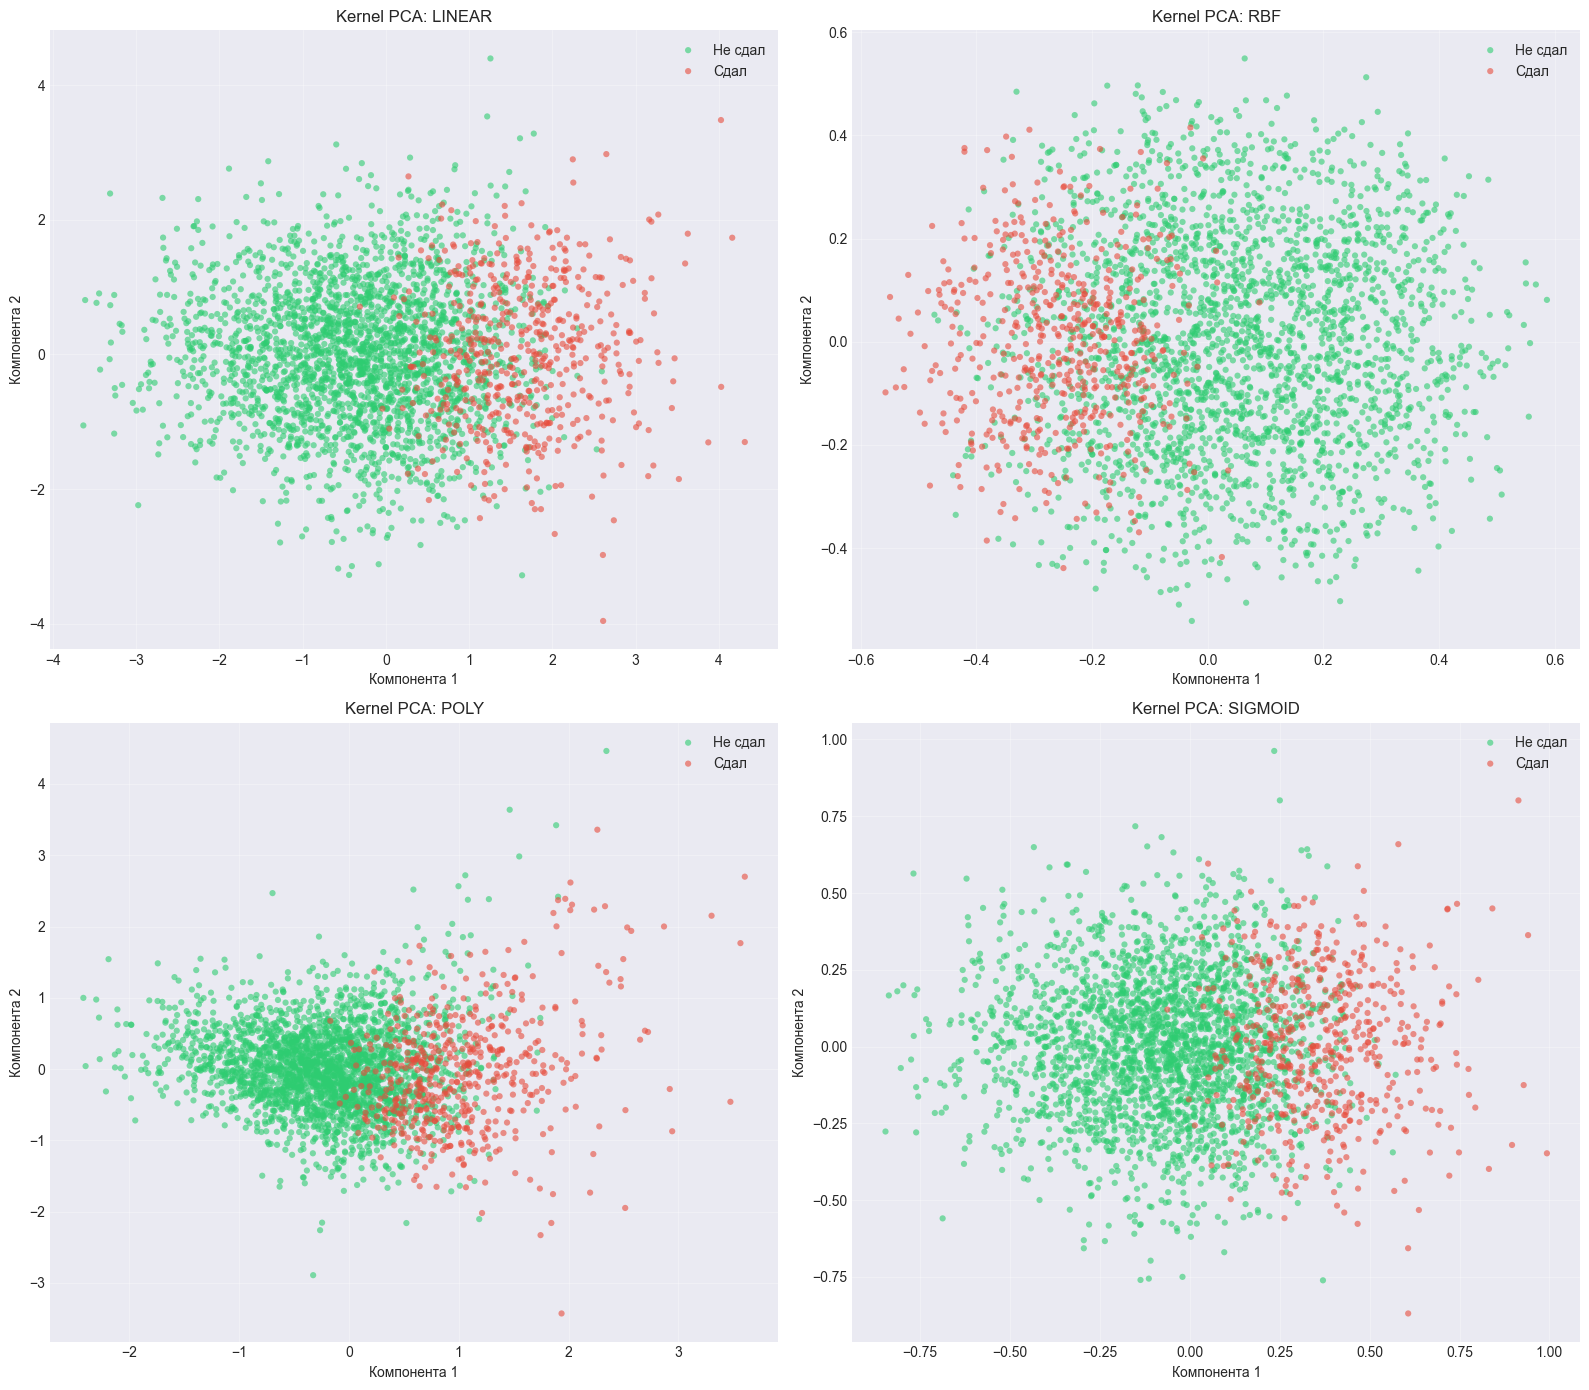

In [4]:
# Визуализация результатов Kernel PCA
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

colors = ['#2ecc71', '#e74c3c']
labels_map = {0: 'Не сдал', 1: 'Сдал'}

for idx, kernel in enumerate(kernels):
    X_kpca = kpca_results[kernel]
    
    for label, color in zip([0, 1], colors):
        mask = y == label
        axes[idx].scatter(X_kpca[mask, 0], X_kpca[mask, 1],
                         c=color, label=labels_map[label], alpha=0.6, s=20, edgecolors='none')
    
    axes[idx].set_title(f'Kernel PCA: {kernel.upper()}')
    axes[idx].set_xlabel('Компонента 1')
    axes[idx].set_ylabel('Компонента 2')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

RBF ядро показывает лучшее разделение классов. Linear ядро даёт результат, близкий к обычному PCA. Sigmoid ядро создаёт интересную нелинейную структуру.

## 5. Влияние параметра gamma (RBF ядро)

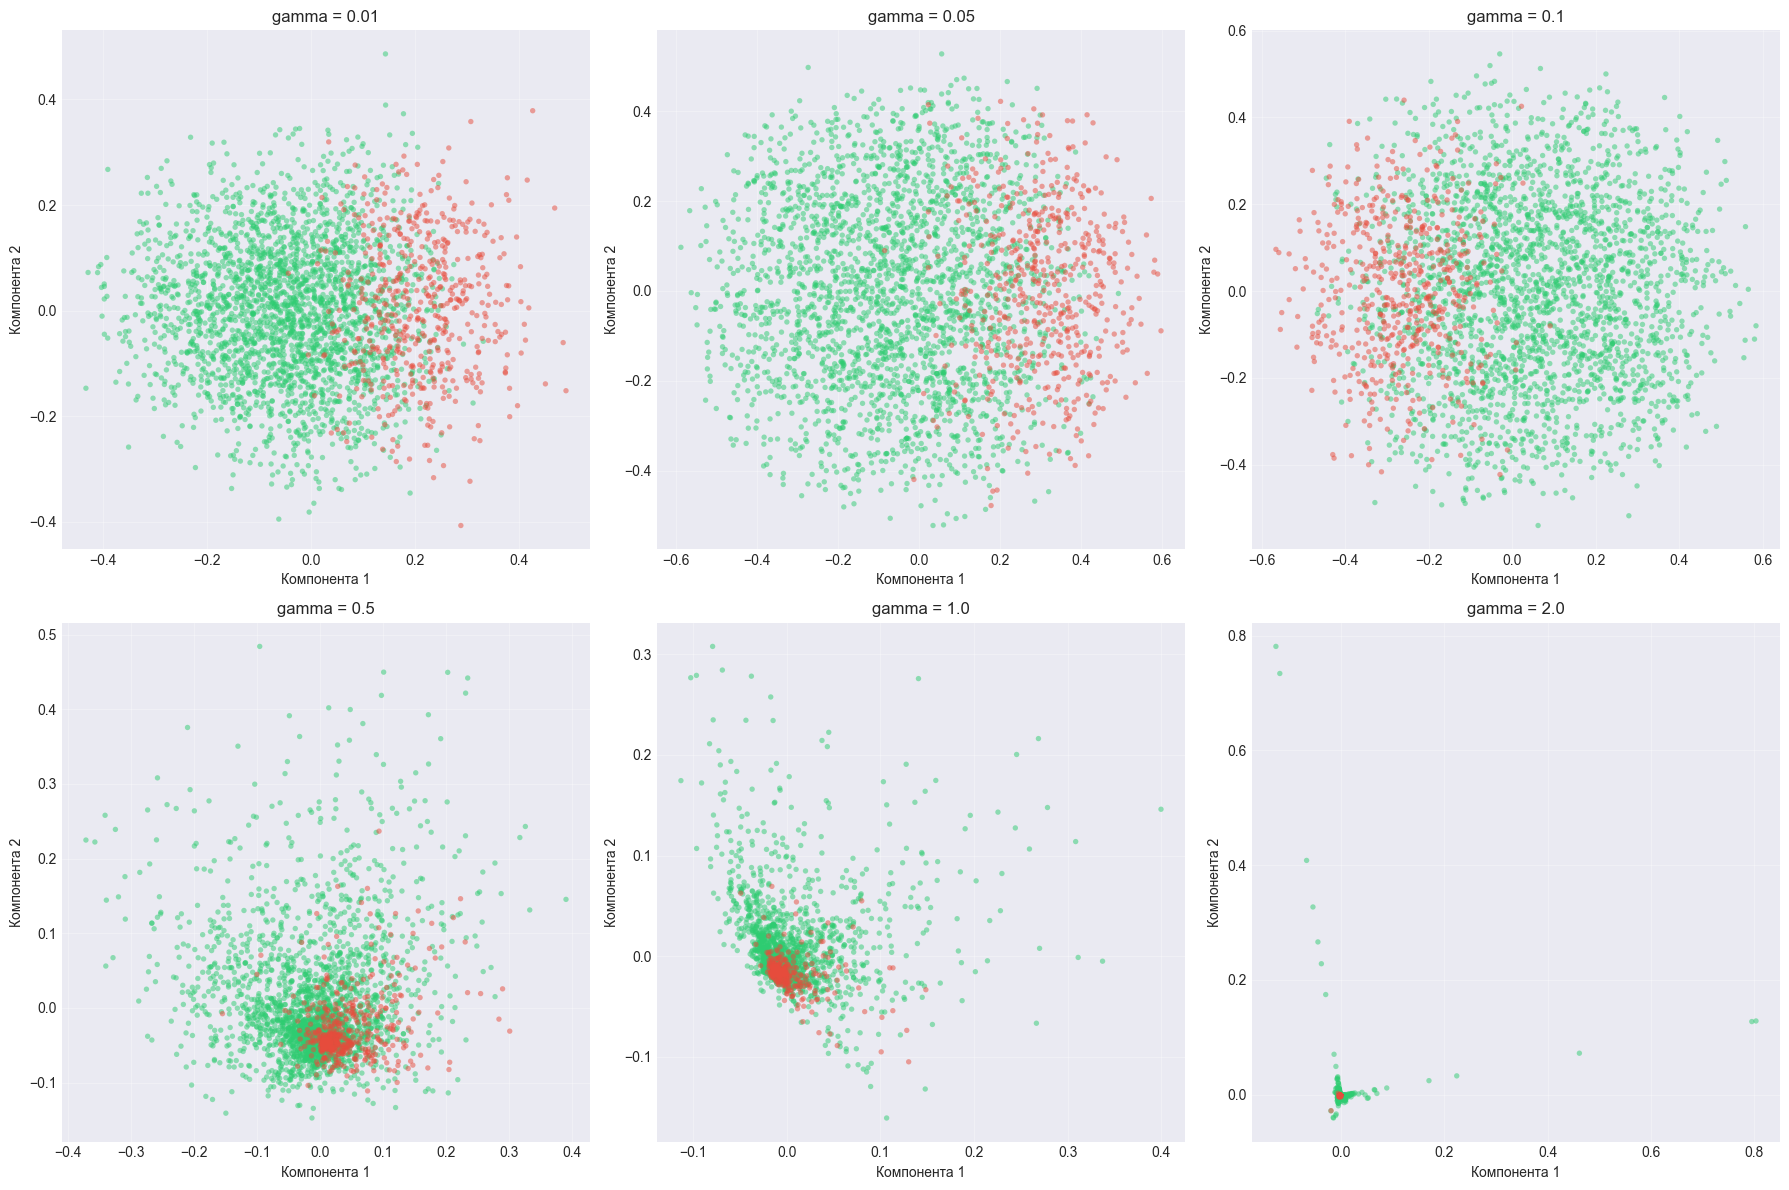

In [5]:
# Исследование влияния gamma на RBF ядро
gammas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, gamma in enumerate(gammas):
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma, random_state=42)
    X_kpca = kpca.fit_transform(X_scaled)
    
    for label, color in zip([0, 1], colors):
        mask = y == label
        axes[idx].scatter(X_kpca[mask, 0], X_kpca[mask, 1],
                         c=color, alpha=0.5, s=15, edgecolors='none')
    
    axes[idx].set_title(f'gamma = {gamma}')
    axes[idx].set_xlabel('Компонента 1')
    axes[idx].set_ylabel('Компонента 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Малые gamma (0.01-0.05) дают глобальную структуру, похожую на PCA. Большие gamma (1.0-2.0) захватывают локальные структуры, но могут переобучаться. Оптимальное gamma ≈ 0.1-0.5.

## 6. Влияние степени полинома (poly ядро)

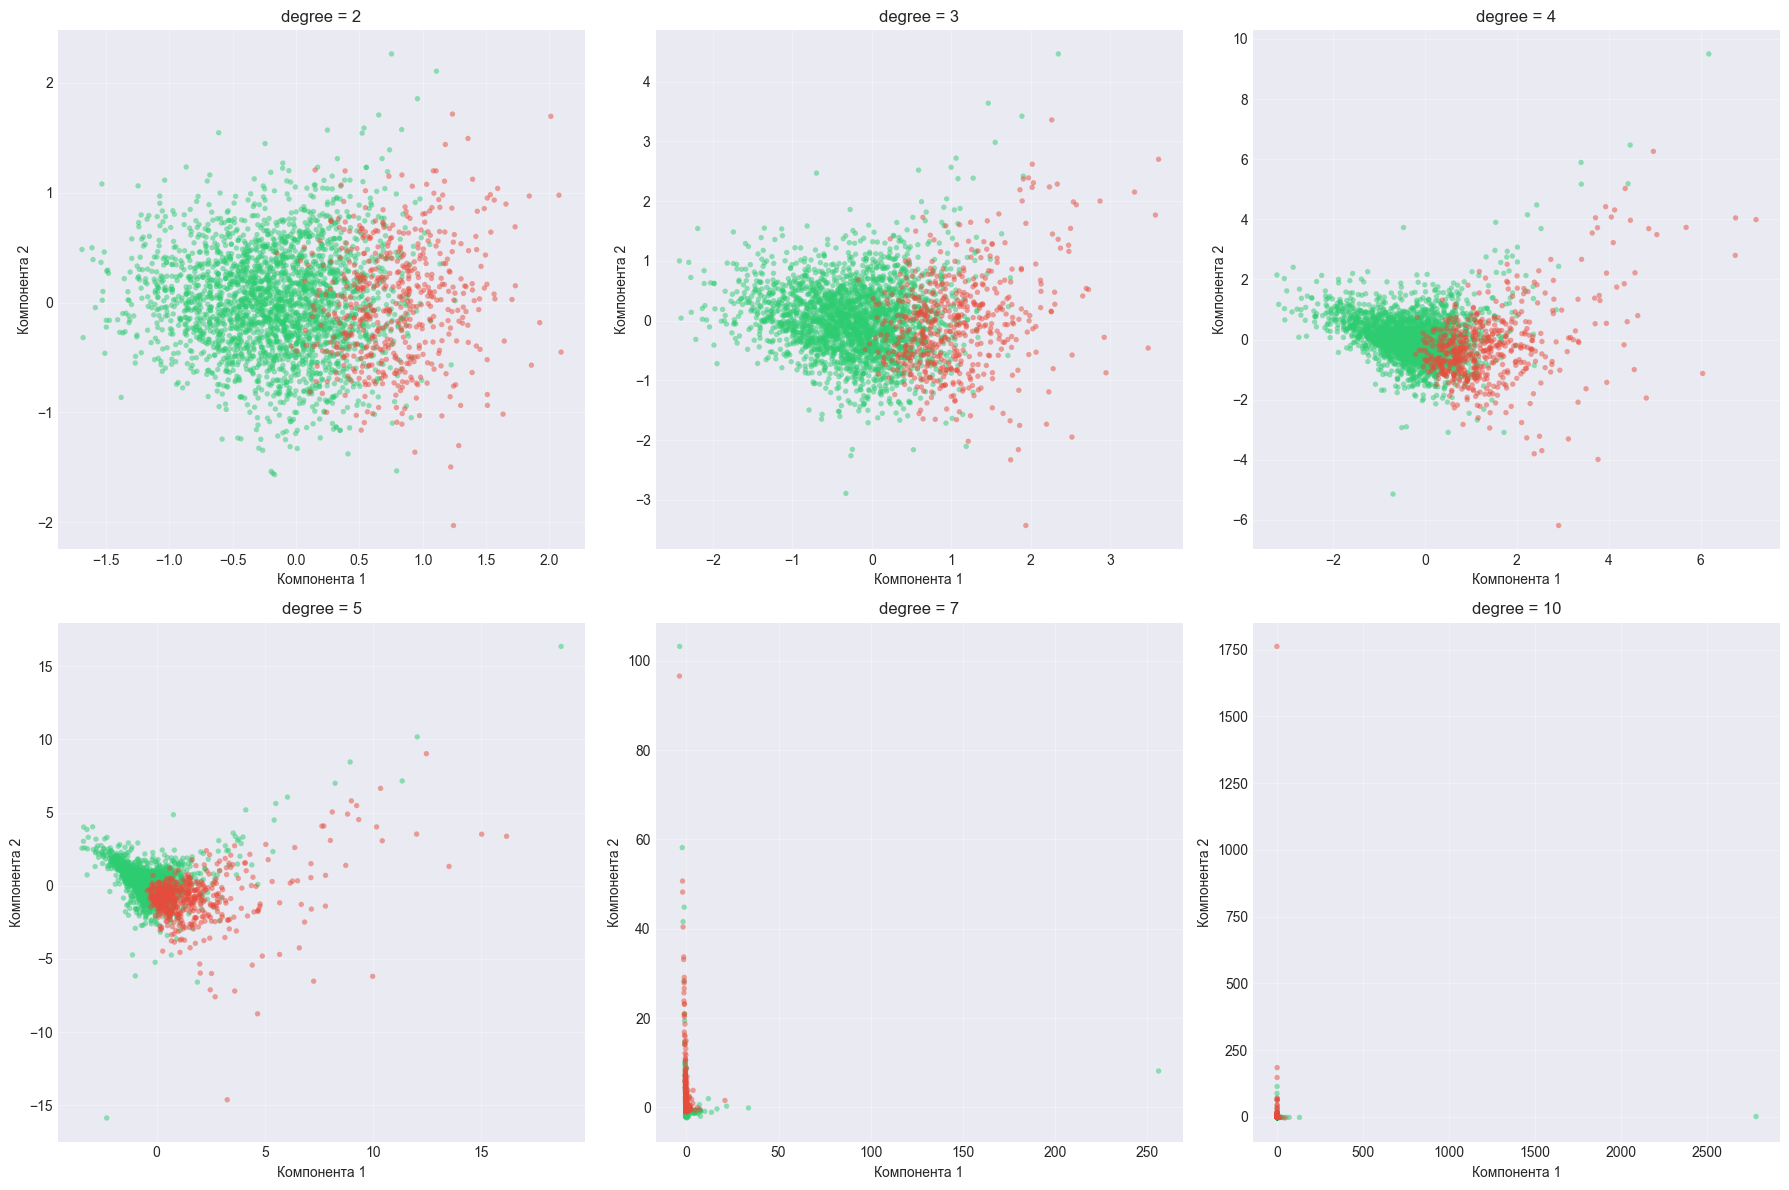

In [6]:
# Исследование влияния степени полинома
degrees = [2, 3, 4, 5, 7, 10]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, degree in enumerate(degrees):
    kpca = KernelPCA(n_components=2, kernel='poly', degree=degree, gamma=1/9, coef0=1, random_state=42)
    X_kpca = kpca.fit_transform(X_scaled)
    
    for label, color in zip([0, 1], colors):
        mask = y == label
        axes[idx].scatter(X_kpca[mask, 0], X_kpca[mask, 1],
                         c=color, alpha=0.5, s=15, edgecolors='none')
    
    axes[idx].set_title(f'degree = {degree}')
    axes[idx].set_xlabel('Компонента 1')
    axes[idx].set_ylabel('Компонента 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Степень 2-3 даёт хорошее разделение. Высокие степени (7-10) создают сложную структуру, но могут переобучаться. Оптимальная степень ≈ 3.

## 7. Сравнение Kernel PCA с обычным PCA

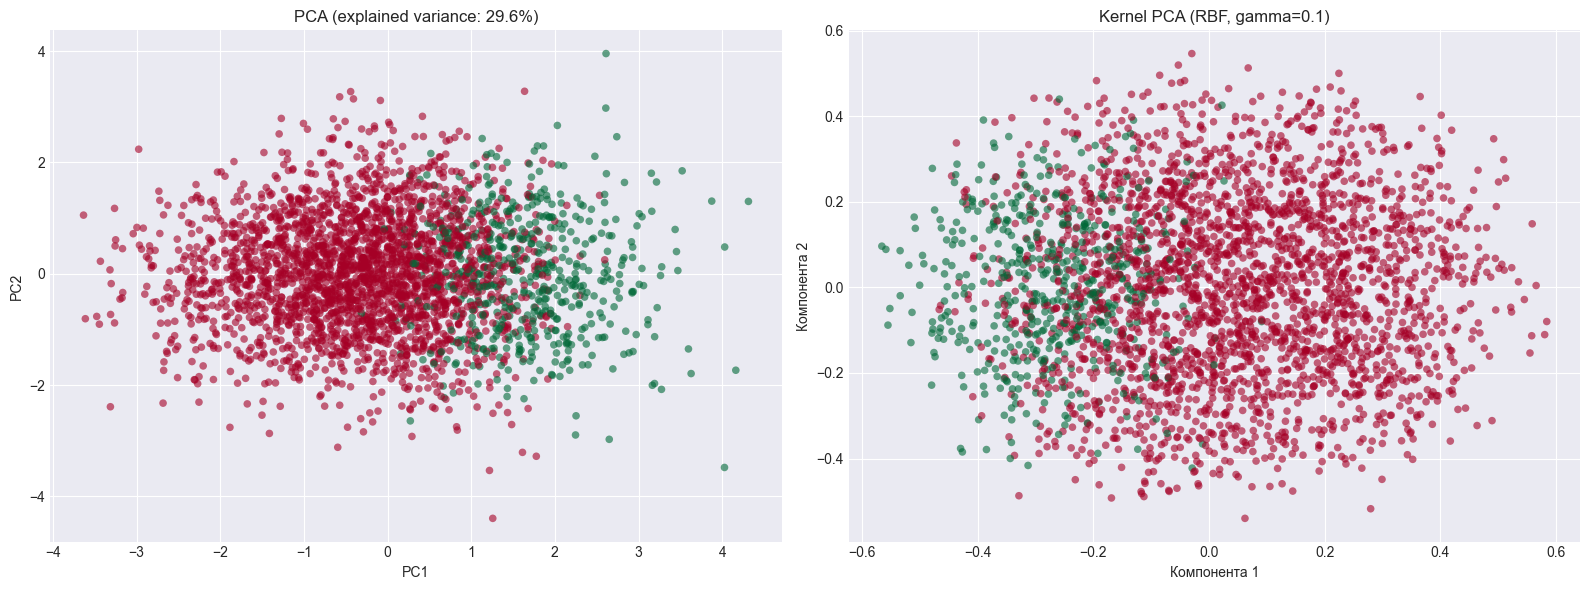

In [7]:
# Сравнение PCA и лучшего Kernel PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Лучшее RBF ядро
kpca_rbf = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=42)
X_kpca_rbf = kpca_rbf.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdYlGn', alpha=0.6, s=30, edgecolors='none')
axes[0].set_title(f'PCA (explained variance: {sum(pca.explained_variance_ratio_):.1%})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_kpca_rbf[:, 0], X_kpca_rbf[:, 1], c=y, cmap='RdYlGn', alpha=0.6, s=30, edgecolors='none')
axes[1].set_title('Kernel PCA (RBF, gamma=0.1)')
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')

plt.tight_layout()
plt.show()

Kernel PCA с RBF ядром создаёт более компактные кластеры. Обычный PCA сохраняет глобальную линейную структуру. Kernel PCA лучше подходит для нелинейных данных.

## 8. Оценка качества разделения

In [8]:
# Оценка качества разделения через silhouette score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print('Сравнение методов по Silhouette Score (k=2):')
print('=' * 50)

# PCA
kmeans_pca = KMeans(n_clusters=2, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, labels_pca)
print(f'PCA: {sil_pca:.4f}')

# Kernel PCA с разными ядрами
for kernel in kernels:
    X_kpca = kpca_results[kernel]
    kmeans = KMeans(n_clusters=2, random_state=42)
    labels = kmeans.fit_predict(X_kpca)
    sil = silhouette_score(X_kpca, labels)
    print(f'Kernel PCA ({kernel}): {sil:.4f}')

Сравнение методов по Silhouette Score (k=2):
PCA: 0.3457
Kernel PCA (linear): 0.3457
Kernel PCA (rbf): 0.3486
Kernel PCA (poly): 0.3473
Kernel PCA (sigmoid): 0.3415


Silhouette Score показывает качество кластеризации в пониженном пространстве. RBF ядро обычно даёт лучший результат для нелинейных данных.